# Module 10 Lab - Unsupervised Learning

**Objective:** To understand and apply two common **unsupervised learning** techniques: **K-Means Clustering** for finding groups in data and **Principal Component Analysis (PCA)** for dimensionality reduction.

**In this lab, you will write the code to perform clustering and PCA, and you will interpret the results.**

## Part 1: Supervised vs. Unsupervised Learning

So far, every model we have built has been a **supervised learning** model. This means we had **labeled data**—we had both the features (X) and the correct answer, or target (y). The goal was to learn a mapping from X to y.

In **unsupervised learning**, we only have the features (X). There is **no target variable**. The goal is to discover interesting structures or patterns hidden in the data on its own.

Two major types of unsupervised learning are:
*   **Clustering:** Automatically grouping similar data points together.
*   **Dimensionality Reduction:** Compressing the data by reducing the number of features while trying to preserve as much information as possible.

## Part 2: K-Means Clustering

**Concept:** K-Means is an algorithm that finds a pre-defined number of clusters (`k`) in a dataset. It works by:
1.  Randomly placing `k` centroids (the center of a cluster) in the data.
2.  **Assignment Step:** Assigning each data point to its nearest centroid.
3.  **Update Step:** Moving each centroid to the average position of all the points assigned to it.
4.  Repeating steps 2 and 3 until the centroids stop moving.

**Problem:** We will use a synthetic dataset of customer spending habits to segment them into groups.

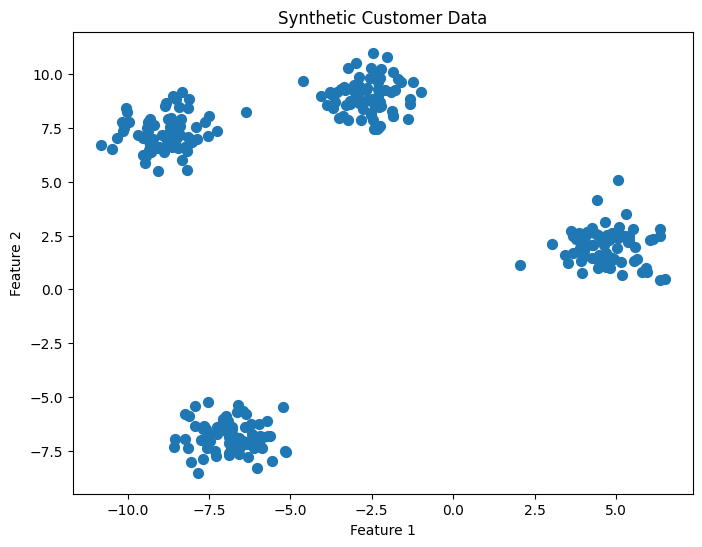

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Generate synthetic data
X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)

# Visualize the data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title("Synthetic Customer Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

### Task 1: Find the Optimal Number of Clusters (The Elbow Method)

**Concept:** How do we know what `k` should be? The **Elbow Method** helps us decide. We run K-Means for a range of `k` values and for each `k`, we calculate the **inertia** (the sum of squared distances of samples to their closest cluster center). We then plot the inertia for each `k`. The "elbow" of the curve—the point where the inertia starts to decrease much more slowly—is a good estimate for the optimal `k`.

**Your Task:** Calculate and plot the inertia for `k` values from 1 to 10.

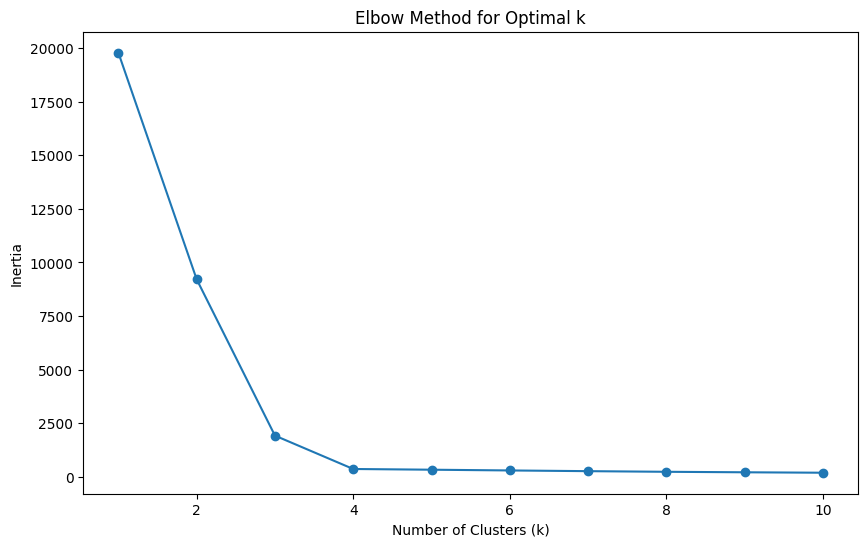

Inertia values:
k=1: 19780.25
k=2: 9211.21
k=3: 1919.36
k=4: 362.47
k=5: 329.27
k=6: 294.61
k=7: 261.56
k=8: 232.01
k=9: 209.10
k=10: 188.72


In [2]:
from sklearn.cluster import KMeans

# --- ENTER YOUR CODE HERE ---

# 1. Create an empty list to store the inertia values
inertia = []

# 2. Loop through k values from 1 to 10
for k in range(1, 11):
    # 3. Create and fit a KMeans model with `n_clusters=k`
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)

    # 4. Append the model's inertia_ to your list
    inertia.append(kmeans.inertia_)

# 5. Plot the results
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.show()

print("Inertia values:")
for k, value in zip(range(1, 11), inertia):
    print(f"k={k}: {value:.2f}")

### Task 2: Perform K-Means Clustering and Visualize

From the elbow plot, it looks like `k=4` is the optimal number of clusters.

**Your Task:** Run K-Means with `n_clusters=4` and create a scatter plot showing the data points colored by their assigned cluster.

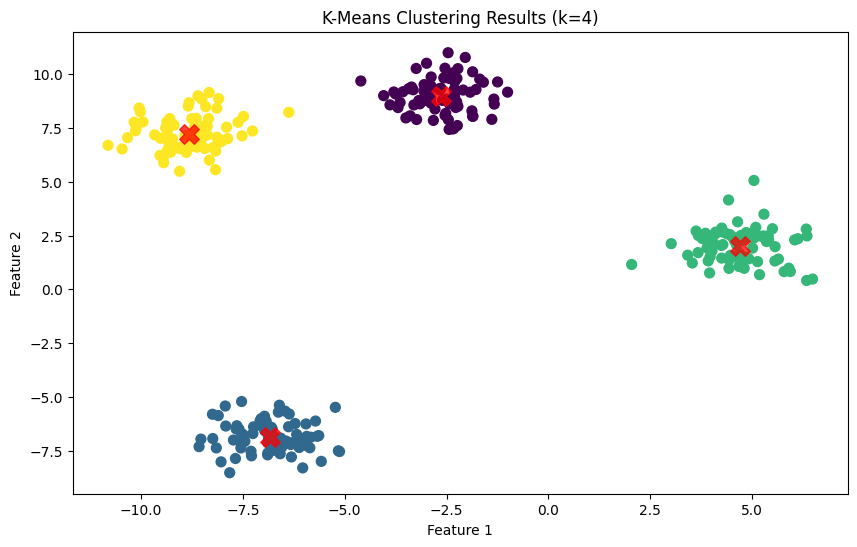

In [3]:
# --- ENTER YOUR CODE HERE ---

# 1. Create and fit a KMeans model with n_clusters=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X)

# 2. Get the cluster assignments for each data point
labels = kmeans.labels_

# 3. Get the coordinates of the cluster centers
centers = kmeans.cluster_centers_

# 4. Create a scatter plot of the data, colored by the labels
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis')
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X') # Plot the centers
plt.title('K-Means Clustering Results (k=4)')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## Part 3: Principal Component Analysis (PCA)

**Concept:** PCA is a dimensionality reduction technique. It transforms the data into a new coordinate system of **principal components**. These components are orthogonal (uncorrelated) and are ordered by the amount of variance in the data they explain. By keeping only the first few principal components, we can reduce the number of dimensions in our data while losing as little information as possible.

**Use Cases:**
*   **Visualization:** Reducing high-dimensional data to 2 or 3 dimensions so we can plot it.
*   **Performance:** Speeding up model training by using fewer features.

**Problem:** We will use the Iris dataset, which has 4 features, and reduce it to 2 features so we can visualize it.

### Task 3: Apply PCA to the Iris Dataset

**Your Task:** Use `PCA` from `sklearn.decomposition` to reduce the 4-dimensional Iris dataset to 2 principal components and visualize the result.

Explained variance by component: [0.92461872 0.05306648]
Total variance explained by 2 components: 97.77%


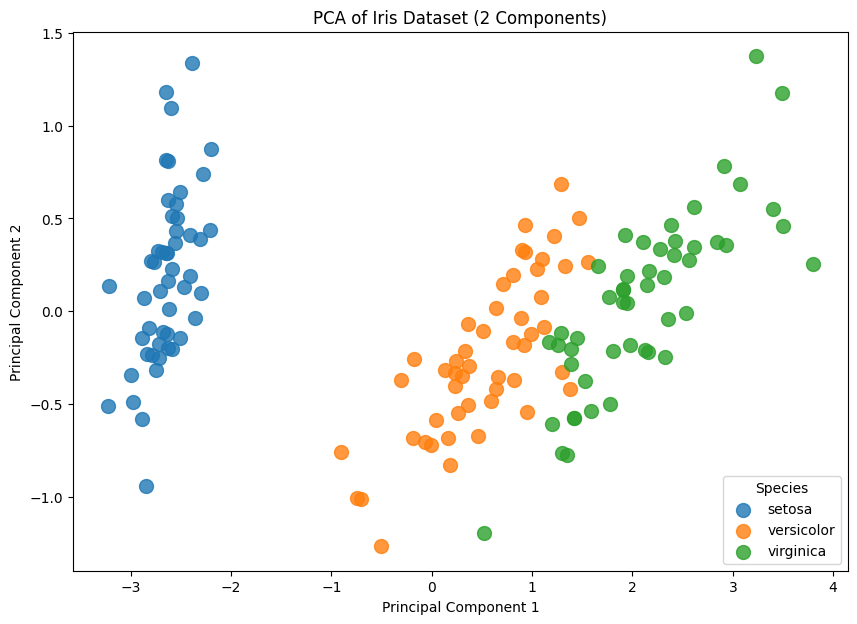

In [4]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
import pandas as pd

# Load the data
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# --- ENTER YOUR CODE HERE ---

# 1. Create a PCA instance to reduce to 2 components
pca = PCA(n_components=2)

# 2. Fit PCA to the data and transform it
X_pca = pca.fit_transform(X_iris)

# 3. Print the explained variance ratio
print(f"Explained variance by component: {pca.explained_variance_ratio_}")
print(f"Total variance explained by 2 components: {pca.explained_variance_ratio_.sum():.2%}")

# 4. Create a DataFrame with the PCA results for plotting
pca_df = pd.DataFrame(data=X_pca, columns=["Principal Component 1", "Principal Component 2"])
pca_df["Species"] = y_iris

# 5. Plot the results
# plt.figure(figsize=(10, 7))
# sns.scatterplot(x="Principal Component 1", y="Principal Component 2", hue="Species", data=pca_df, palette='viridis', s=100)
# plt.title('PCA of Iris Dataset (2 Components)')
# plt.show()

plt.figure(figsize=(10, 7))

for species_id, species_name in enumerate(iris.target_names):
    subset = pca_df[pca_df["Species"] == species_id]
    plt.scatter(
        subset["Principal Component 1"],
        subset["Principal Component 2"],
        s=100,
        label=species_name,
        alpha=0.8
    )

plt.title("PCA of Iris Dataset (2 Components)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Species")
plt.show()


## 📝 Knowledge Check

**Instructions:** Answer the following questions in this markdown cell.

### **1.  What is the fundamental difference between supervised and unsupervised learning?**

**[Huong]**

The fundamental difference is that **supervised learning uses labeled data**, while **unsupervised learning does not**.

In this lab, K-Means clustering groups the Iris data purely based on feature similarity without using the species labels. The model identifies patterns directly from the feature space. In contrast, supervised learning would use the known species labels to learn explicit class boundaries.

This difference is reflected in the workflow: K-Means assigns cluster labels based only on distance, while supervised models would evaluate performance against true labels.

**[Allisa]: [ENTER YOUR ANSWERS HERE]**

**[Stuart]: **

Supervised uses labeled data to create categories and derive weights, where unsupervised relies on the algorithym's clustering to find categories in messy or complex data. Supervised requires more upfront work to understand and properly feature engineer for optimal training performance, where unsupervised requires a feedback loop of training budgeting, observations, and adjustments to get a meaningful outcome.

**[Ruben]: [ENTER YOUR ANSWERS HERE]**

### **2.  In the K-Means elbow plot, why don't we just choose the largest possible `k` to get the lowest inertia?**

**[Huong]**

Although inertia continuously decreases as k increases, the elbow plot shows that the **rate of improvement drops significantly after k = 3**.

In the chart, inertia decreases sharply from k = 1 to k = 3, then flattens, meaning additional clusters provide only marginal reduction in inertia. Choosing a very large k would artificially lower inertia by creating small, fragmented clusters that do not represent meaningful structure.

Therefore, k = 3 is selected because it balances model simplicity and performance, capturing the natural grouping in the data without overfitting.

**[Allisa]: [ENTER YOUR ANSWERS HERE]**

**[Stuart]: **

Choosing the largest possible K would result in overfitting the model, where the elbow plot shows performance improvement flattens out around K = 3 or 4. Using beyond this would lead to the model no longer being able to generalize beyond the training data and perform poorly in real-world use.

**[Ruben]: [ENTER YOUR ANSWERS HERE]**

### **3.  In the PCA results, the first two principal components explained over 95% of the variance. What does this tell you about the original 4-dimensional Iris dataset?**

**[Huong]**

The fact that the first two principal components explain over **95% of the total variance** indicates that most of the information in the original 4-dimensional dataset can be represented in just 2 dimensions.

This means the features are highly correlated and do not contribute independent information. As a result, dimensionality can be reduced from 4D to 2D with minimal information loss.

This is also consistent with the clustering results, where the data can be effectively separated in a lower-dimensional space, confirming that the underlying structure of the Iris dataset is relatively simple.

**[Allisa]: [ENTER YOUR ANSWERS HERE]**

**[Stuart]: **

With the two components explaining 95%, this shows that the extra 2 components can be removed from the training features to simplify the training process and compute requirements without sacrificing overall perfomance. 

**[Ruben]: [ENTER YOUR ANSWERS HERE]**